In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from scipy.special import sici
from scipy.interpolate import interp1d

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels
from scipy.optimize import curve_fit

def mm(cc, cx, xx, fx=0.1):
    return (1-fx)**2 *cc+fx*(1-fx)*cx+fx**2 * xx

plt.rcParams.update({
    'font.size': 10,          # base font size
    'axes.labelsize': 10,     # axis label size
    'axes.titlesize': 10,     # title size
    'xtick.labelsize': 9,     
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


In [5]:
fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=1
supprshift=8
p=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)


In [66]:
keval = np.logspace(-3,3,100)
etaval = np.linspace(-8,9,100)
g_vals = nk.g_an(etaval)
h_vals = nk.h_an(etaval)

b1 = 1.5
bx = 0.5
bT = 0.3

Pgg1 = (b1 + bx*g_vals +bT*(h_vals-1))**2


Pgg3 = (1.2 + 0.8*g_vals)**2

In [67]:
from scipy.optimize import minimize

def func(b12, bx2):
    return (b12 + bx2*g_vals)**2

def objective(params):
    b12, bx2 = params 
    residuals = (Pgg1 - func(b12, bx2))/Pgg1
    return np.sum(np.abs(residuals)**2)

result = minimize(objective, [1.5,0.5])
b12, bx2 = result.x
Pgg2 = (b12 + bx2*g_vals)**2

print(result.x)

[1.21170957 0.81136209]


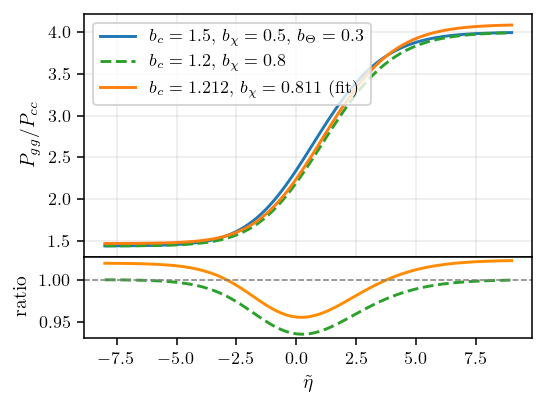

In [70]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1],'hspace':0}, figsize=(4, 3), dpi=140)

# Upper panel: Plot Pgg1, Pgg2, and Pgg3
ax1.plot(etaval, Pgg1, label='$b_c = 1.5$, $b_\chi = 0.5$, $b_\Theta = 0.3$')
ax1.plot(etaval, Pgg3,c='tab:green',ls='--', label='$b_c = 1.2$, $b_\chi = 0.8$')

ax1.plot(etaval, Pgg2, label=fr'$b_c = {b12:.3f}$, $b_\chi = {bx2:.3f}$ (fit)')
ax1.set_ylabel('$P_{gg}/P_{cc}$')
ax1.legend()
ax1.grid(lw=0.2)

# Lower panel: Plot ratios
ax2.plot(etaval, Pgg3 / Pgg1,c='tab:green',ls='--',label='$b_c = 0.8$, $b_\chi = 1.2$')
ax2.plot(etaval, Pgg2 / Pgg1, c='darkorange',label='fit')
ax2.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel(r'$\tilde \eta$')
ax2.set_ylabel('ratio')
# ax2.legend()
# ax2.grid()

plt.tight_layout()
plt.show()

---

In [7]:
fx=0.15
t_ini = -7
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=0.3
supprshift=8
p=0
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001, p=p, supprshift=supprshift)

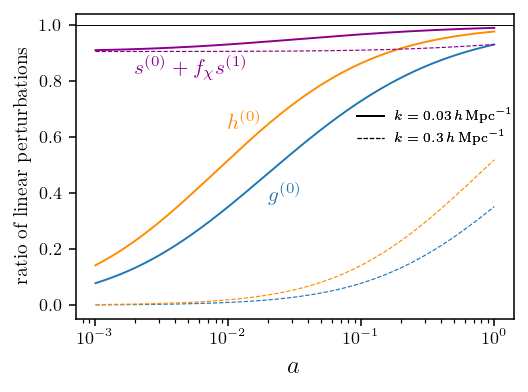

In [53]:
fig, ax = plt.subplots(figsize=(3.9, 2.9), dpi=140)

def g_an_a(a, kOks):
    return nk.g_an(np.log(a)-(2+p)*np.log(kOks))
def h_an_a(a, kOks):
    return nk.h_an(np.log(a)-(2+p)*np.log(kOks))
def s_an_a(a, kOks):
    return nk.g_c_int(np.log(a)-(2+p)*np.log(kOks))

kT1 = 0.03
kT2 = 0.3

avals = np.logspace(-3,0,200)

ax.plot(avals, g_an_a(avals, kT1/kref), lw=1., c='tab:blue')
ax.plot(avals, g_an_a(avals, kT2/kref), lw=0.6, ls='--', c='tab:blue')
ax.plot(avals, h_an_a(avals, kT1/kref), lw=1., c='darkorange')
ax.plot(avals, h_an_a(avals, kT2/kref), lw=0.6, ls='--', c='darkorange')
ax.plot(avals, s_an_a(avals, kT1/kref), lw=1., c='darkmagenta')
ax.plot(avals, s_an_a(avals, kT2/kref), lw=0.6, ls='--', c='darkmagenta')

legend1 = ax.legend([plt.Line2D([0], [0], color='k', lw=1.),
                     plt.Line2D([0], [0], color='k', linestyle='--', lw=0.6)], 
                    [f'$k={kT1}'+r'\,h\,\mathrm{Mpc}^{-1}$', f'$k={kT2}'+r'\,h\,\mathrm{Mpc}^{-1}$'], 
                    loc='center right', fontsize=7, frameon=False, bbox_to_anchor=(1.025, 0.63))
ax.add_artist(legend1)

ax.text(2.e-3, 0.85, r'$s^{(0)}+f_\chi s^{(1)}$', color='darkmagenta', fontsize=11, va='center', rotation=0)
ax.text(1.e-2, 0.65, r'$h^{(0)}$', color='darkorange', fontsize=11, va='center', rotation=0)
ax.text(2.e-2, 0.4, r'$g^{(0)}$', color='tab:blue', fontsize=11, va='center', rotation=0)

ax.axhline(1., lw=0.5, c='k')
ax.set_xscale('log')
ax.set_xlabel(r'$a$', fontsize=13)
ax.set_ylabel(r'ratio of linear perturbations', fontsize=10)
# ax.grid(lw=0.05)

plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/ghs_asfunc_a.pdf', bbox_inches='tight')

plt.show()


In [ ]:
nk.g_c_int

0.35238593891205383